Question 9 

Face Mask Detection 

Fine-tune a pretrained MobileNet model on a face-mask dataset. Evaluate precision, recall and inference speed. Suggest optimizations for edge deployment. 

Expected Deliverables: Training code, evaluation and optimization notes.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import time

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [2]:
DATASET = "face_mask_dataset"

IMG_SIZE = (224,224)

BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Found 7553 files belonging to 2 classes.
Using 1510 files for validation.
['with_mask', 'without_mask']


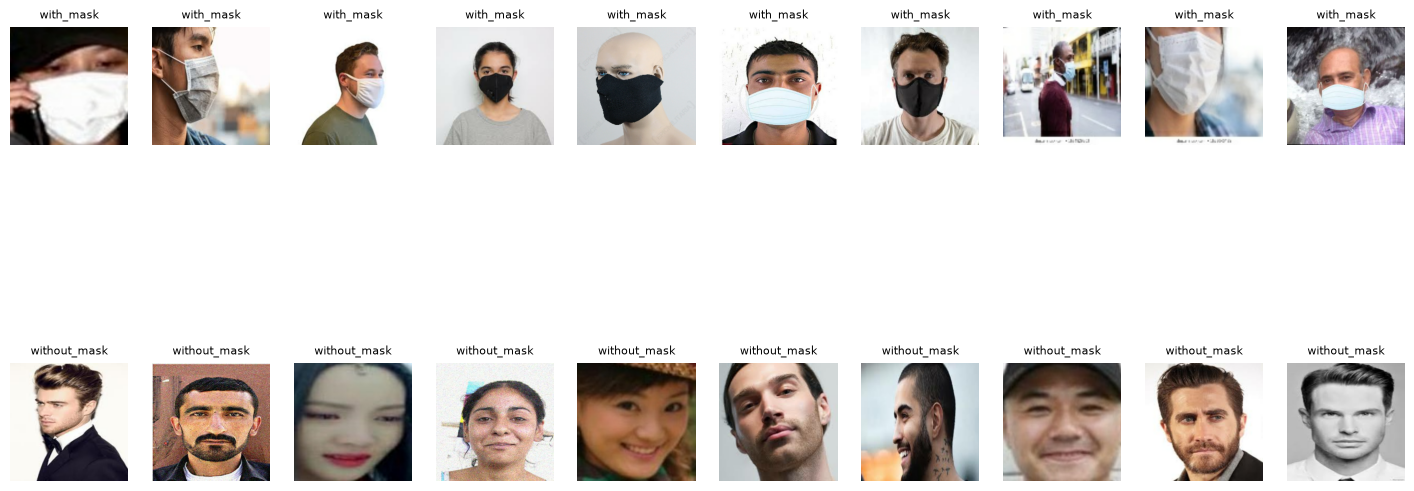

In [3]:
images = []
labels = []

for image_batch, label_batch in train_ds:

    images.extend(image_batch.numpy())
    labels.extend(label_batch.numpy())

images = np.array(images)
labels = np.array(labels)

plt.figure(figsize=(18,8))

plot_index = 1

for cls in range(len(class_names)):

    idx = np.where(labels==cls)[0]

    random_idx = np.random.choice(idx,10,replace=False)

    for i in random_idx:

        plt.subplot(2,10,plot_index)

        plt.imshow(images[i].astype("uint8"))

        plt.axis("off")

        plt.title(class_names[cls],fontsize=8)

        plot_index +=1

plt.show()

In [4]:
data_augmentation = Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2)

])

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

In [6]:
base_model = MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights="imagenet"

)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
base_model.trainable = False

In [9]:
model = Sequential([

    data_augmentation,

    layers.Rescaling(1./127.5,offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128,activation="relu"),

    layers.Dense(1,activation="sigmoid")

])

In [10]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]

)

In [11]:
checkpoint = ModelCheckpoint(

    "best_mask_detector.keras",

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_accuracy",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

In [12]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[checkpoint,early_stop]

)

Epoch 1/15


C:\Users\gouth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9596 - loss: 0.1035 - precision: 0.9601 - recall: 0.9601
Epoch 1: val_accuracy improved from None to 0.99139, saving model to best_mask_detector.keras

Epoch 1: finished saving model to best_mask_detector.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 63s 312ms/step - accuracy: 0.9596 - loss: 0.1035 - precision: 0.9601 - recall: 0.9601 - val_accuracy: 0.9914 - val_loss: 0.0213 - val_precision: 0.9961 - val_recall: 0.9870
Epoch 2/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9780 - loss: 0.0626 - precision: 0.9775 - recall: 0.9791
Epoch 2: val_accuracy improved from 0.99139 to 0.99205, saving model to best_mask_detector.keras

Epoch 2: finished saving model to best_mask_detector.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 57s 303ms/step - accuracy: 0.9780 - loss: 0.0626 - precision: 0.9775 - recall: 0.9791 - val_accuracy: 0.9921 - val_loss: 0.0246 - val_precision: 0.9961 - val_recall: 0.9883
Epoch 3/15
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 267

In [13]:
model.evaluate(val_ds)

48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.9967 - loss: 0.0126 - precision: 0.9987 - recall: 0.9948


[0.012641549110412598,
 0.996688723564148,
 0.9986928105354309,
 0.9947916865348816]

In [14]:
model.save("face_mask_detector.keras")

In [15]:
sample = next(iter(val_ds))

img = sample[0][0]

img = np.expand_dims(img,0)

start = time.time()

prediction = model.predict(img)

end = time.time()

print("Inference Time:",(end-start)*1000,"ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
Inference Time: 891.7763233184814 ms


In [2]:
from tensorflow.keras.models import load_model

model = load_model("best_mask_detector.keras")

In [3]:
face_cascade = cv2.CascadeClassifier(

    cv2.data.haarcascades +

    "haarcascade_frontalface_default.xml"

)

In [4]:
cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(

        gray,

        scaleFactor=1.1,

        minNeighbors=5,

        minSize=(50,50)

    )

    for (x,y,w,h) in faces:

        face = frame[y:y+h,x:x+w]

        face = cv2.resize(face,(224,224))

        face = preprocess_input(face.astype(np.float32))

        face = np.expand_dims(face,0)

        prediction = model.predict(face,verbose=0)[0][0]

        if prediction < 0.5:

            label = "Mask"

            color = (0,255,0)

        else:

            label = "No Mask"

            color = (0,0,255)

        cv2.rectangle(frame,(x,y),(x+w,y+h),color,2)

        cv2.putText(

            frame,

            label,

            (x,y-10),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.8,

            color,

            2

        )

    cv2.imshow("Face Mask Detector",frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()

cv2.destroyAllWindows()

## Optimizations for Edge Deployment

- **Convert the model to TensorFlow Lite (.tflite):**
  - Convert the trained `.keras` model to TensorFlow Lite format for deployment on embedded devices.
  - Reduces model size and improves inference speed.

- **Apply Model Quantization:**
  - Convert model weights from `float32` to `int8` or `float16`.
  - Reduces memory usage, increases inference speed, and lowers power consumption with minimal accuracy loss.

- **Use a Lightweight Architecture:**
  - MobileNetV2 is already optimized for mobile and edge devices.
  - It requires fewer parameters and less computation than larger CNNs like ResNet or VGG.

- **Reduce Input Image Resolution:**
  - Resize input images from `224 × 224` to `160 × 160` or `128 × 128` where acceptable.
  - Smaller images reduce computation and improve frame rate.

- **Crop Only the Face Region:**
  - Detect the face first and classify only the cropped face instead of the entire image.
  - Reduces unnecessary processing and improves classification accuracy.

- **Use an Efficient Face Detector:**
  - Replace Haar Cascade with modern detectors such as OpenCV YuNet or OpenCV DNN Face Detector.
  - These provide faster and more reliable face detection, especially for partially occluded (masked) faces.

- **Skip Alternate Video Frames:**
  - Perform inference on every second or third frame instead of every frame.
  - Improves real-time performance while maintaining acceptable detection accuracy.

- **Utilize Hardware Acceleration:**
  - Leverage available hardware such as GPUs, TensorRT, NNAPI, or Edge TPU for faster inference.
  - Significantly reduces prediction latency on supported devices.

- **Use Batch Size of 1 for Inference:**
  - Process one frame at a time during real-time video capture.
  - Minimizes latency and provides immediate predictions.

- **Apply Model Pruning (Optional):**
  - Remove redundant weights after training to reduce model size and computational complexity.
  - Helps improve inference efficiency on resource-constrained devices.

- **Optimize Memory Usage:**
  - Load the model only once during application startup.
  - Reuse buffers and avoid repeated memory allocation during continuous video processing.

- **Deploy on Edge Devices:**
  - The optimized model can be deployed on Raspberry Pi, NVIDIA Jetson Nano, Android devices, or other embedded platforms for real-time face mask detection without relying on cloud services.